# S&P 500 Market Risk Analysis

This report analyzes volatility dynamics and market risk in the S&P 500 using Python.

The analysis includes:

- Daily returns
- Maximum drawdown
- Volatility clustering
- Historical Value at Risk (VaR)
- GARCH volatility modeling

## Data

We download historical data for the S&P 500 index using the yfinance API.

The dataset includes daily prices from 2015 onward.

[*********************100%***********************]  1 of 1 completed


<Figure size 640x480 with 0 Axes>

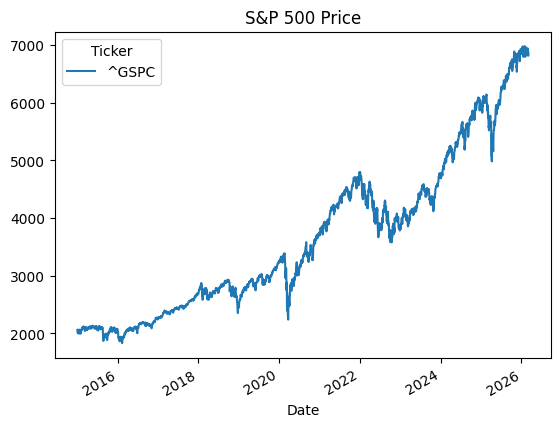

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ticker = "^GSPC"

df = yf.download(ticker, start="2015-01-01", auto_adjust=True)

df["ret"] = df["Close"].pct_change()
df["vol_21d"] = df["ret"].rolling(21).std() * np.sqrt(252)

plt.figure()
df["Close"].plot(title="S&P 500 Price")
plt.show()





### Interpretation

The largest drawdown occurred during the COVID-19 market crash in March 2020, reaching approximately **-34%**.

This event represents the most severe market decline in the analyzed period.

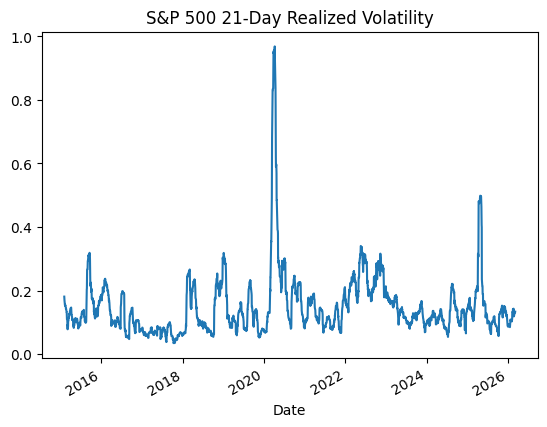

Price,Close,High,Low,Open,Volume,ret,vol_21d
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,,
Date,,,,,,,
2026-02-26,6908.859863,6947.250000,6859.729980,6944.740234,5889550000,-0.005366,0.128349
2026-02-27,6878.879883,6882.959961,6831.740234,6856.540039,6665660000,-0.004339,0.129042
2026-03-02,6881.620117,6901.009766,6796.850098,6824.359863,6079080000,0.000398,0.129069
2026-03-03,6816.629883,6840.049805,6710.419922,6800.259766,6442080000,-0.009444,0.132136
2026-03-04,6869.500000,6885.939941,6811.640137,6831.689941,3193784000,0.007756,0.133779


In [15]:
plt.figure()
df["vol_21d"].plot(title="S&P 500 21-Day Realized Volatility")
plt.show()

df.tail()

### Interpretation

Periods of market stress show clear volatility clustering, where large price movements tend to occur consecutively.

This stylized fact motivates the use of models such as GARCH.

## Returns

We compute daily log returns of the index.  
Returns are the fundamental variable used in most financial models.

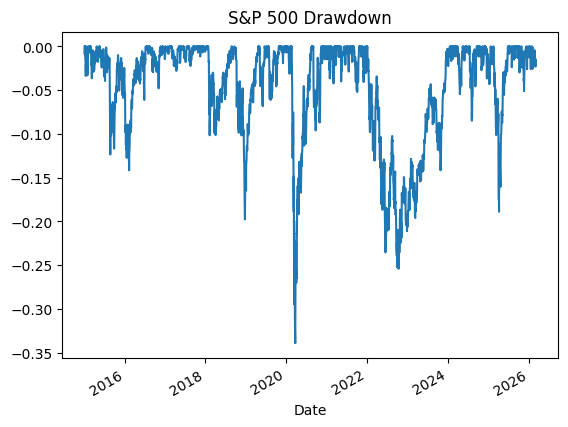

np.float64(-0.33924960002653304)

In [4]:
cum_returns = (1 + df["ret"]).cumprod()

rolling_max = cum_returns.cummax()

drawdown = cum_returns / rolling_max - 1

plt.figure()
drawdown.plot(title="S&P 500 Drawdown")
plt.show()

drawdown.min()

## Maximum Drawdown

Maximum drawdown measures the largest decline from a historical peak.

This metric is widely used to evaluate downside risk in portfolios.

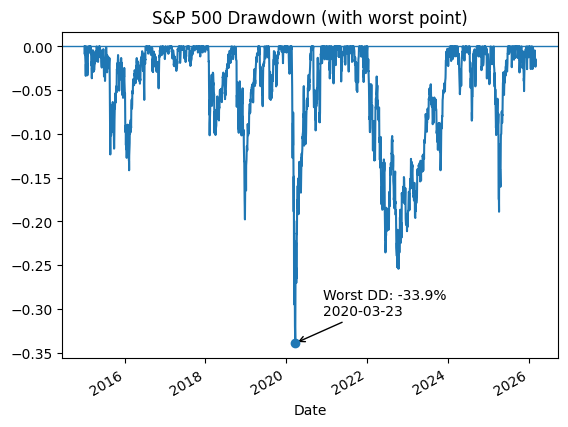

(Timestamp('2020-03-23 00:00:00'), -0.33924960002653304)

In [5]:
# Worst drawdown point
worst_date = drawdown.idxmin()
worst_dd = float(drawdown.min())

plt.figure()
drawdown.plot(title="S&P 500 Drawdown (with worst point)")
plt.scatter(worst_date, worst_dd, zorder=5)
plt.annotate(
    f"Worst DD: {worst_dd:.1%}\n{worst_date.date()}",
    xy=(worst_date, worst_dd),
    xytext=(20, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)
plt.axhline(0, linewidth=1)
plt.show()

worst_date, worst_dd

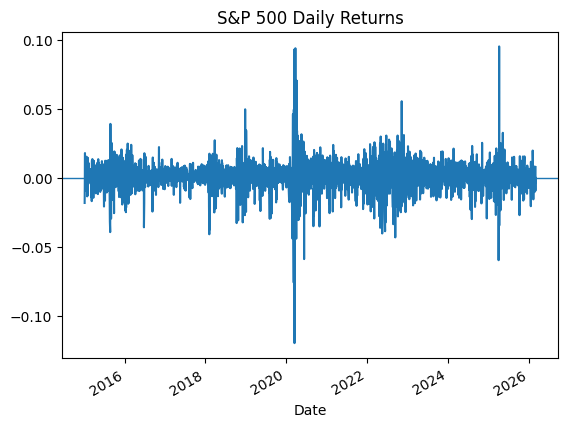

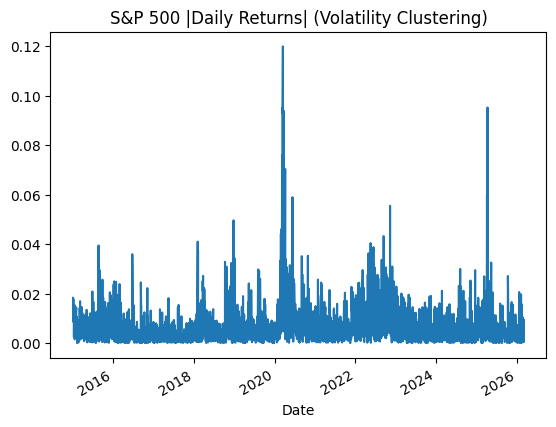

In [6]:
abs_ret = df["ret"].abs()

plt.figure()
df["ret"].plot(title="S&P 500 Daily Returns")
plt.axhline(0, linewidth=1)
plt.show()

plt.figure()
abs_ret.plot(title="S&P 500 |Daily Returns| (Volatility Clustering)")
plt.show()

In [7]:
from statsmodels.tsa.stattools import acf

ret = df["ret"].dropna()
abs_ret = ret.abs()

acf_ret_20 = acf(ret, nlags=20, fft=True)
acf_abs_20 = acf(abs_ret, nlags=20, fft=True)

print("ACF daily returns (lags 1..5):", np.round(acf_ret_20[1:6], 3))
print("ACF abs returns (lags 1..5):  ", np.round(acf_abs_20[1:6], 3))

ACF daily returns (lags 1..5): [-0.135  0.077 -0.036 -0.07   0.04 ]
ACF abs returns (lags 1..5):   [0.369 0.397 0.368 0.36  0.322]


## Value at Risk (VaR)

Value at Risk estimates the maximum expected loss over a given time horizon at a specific confidence level.

We compute historical VaR using daily returns.

VaR 95% (daily): -0.016617232500425082
VaR 99% (daily): -0.032503128587837556


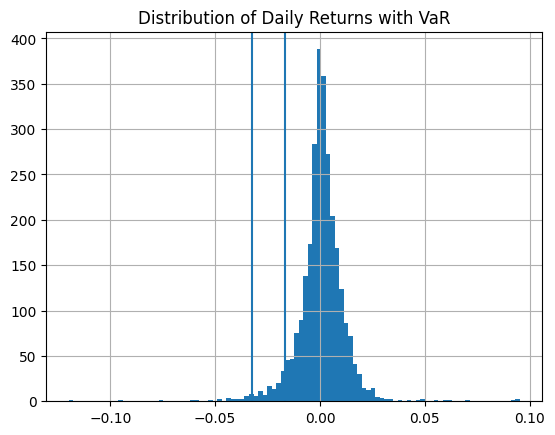

In [8]:
# Historical VaR

returns = df["ret"].dropna()

var_95 = returns.quantile(0.05)
var_99 = returns.quantile(0.01)

print("VaR 95% (daily):", var_95)
print("VaR 99% (daily):", var_99)

plt.figure()
returns.hist(bins=100)
plt.axvline(var_95)
plt.axvline(var_99)
plt.title("Distribution of Daily Returns with VaR")
plt.show()

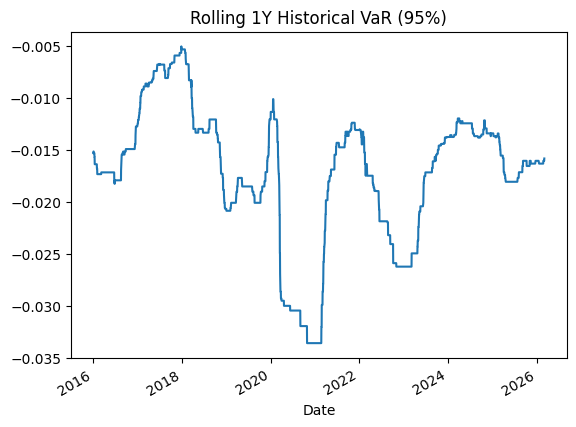

In [9]:
rolling_var = returns.rolling(252).quantile(0.05)

plt.figure()
rolling_var.plot(title="Rolling 1Y Historical VaR (95%)")
plt.show()

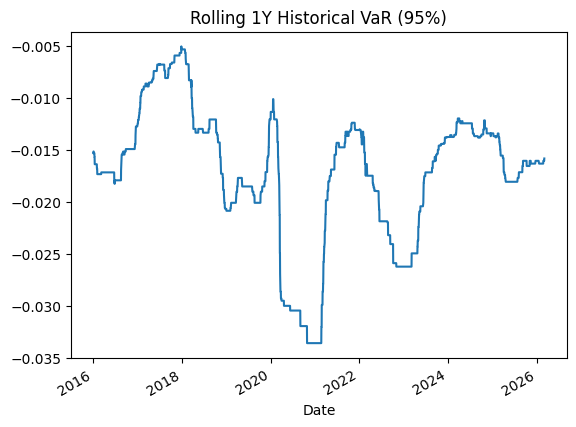

In [10]:
rolling_var = returns.rolling(252).quantile(0.05)

plt.figure()
rolling_var.plot(title="Rolling 1Y Historical VaR (95%)")
plt.show()

## Volatility Modeling (GARCH)

Financial returns exhibit volatility clustering.  
To model this phenomenon we estimate a GARCH(1,1) model.

This allows us to estimate conditional volatility over time.

In [11]:
from arch import arch_model

returns = df["ret"].dropna() * 100  # en %

model = arch_model(returns, vol="Garch", p=1, q=1)

results = model.fit(disp="off")

print(results.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3616.99
Distribution:                  Normal   AIC:                           7241.99
Method:            Maximum Likelihood   BIC:                           7265.75
                                        No. Observations:                 2807
Date:                Wed, Mar 04 2026   Df Residuals:                     2806
Time:                        23:42:21   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0806  1.411e-02      5.710  1.130e-08 [5.293e-0

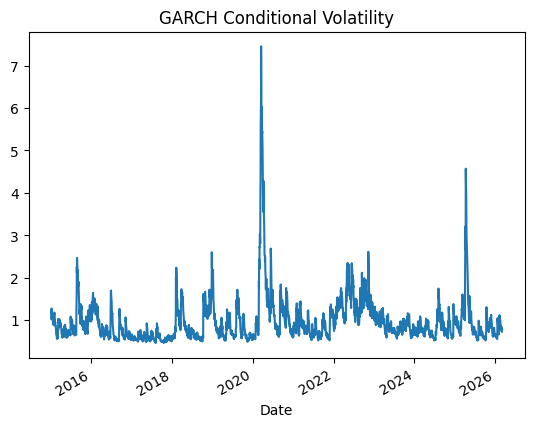

In [12]:
cond_vol = results.conditional_volatility

plt.figure()
cond_vol.plot(title="GARCH Conditional Volatility")
plt.show()

## Conclusion

This analysis highlights several well-known stylized facts of financial markets:

- Equity returns exhibit low autocorrelation.
- Absolute returns show strong persistence, indicating volatility clustering.
- Market risk increases significantly during crisis periods.
- A GARCH(1,1) model captures the persistence of volatility.

These results are consistent with empirical findings in financial econometrics.